<a href="https://colab.research.google.com/github/fiorentinaChang/cross-asset-tsmom-risk/blob/main/cross-asset-tsmom-risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# REAL CROSS-ASSET ETF PROXY DATA — CLEAN EXPANDED UNIVERSE
# Main project universe
# ============================================================

!pip -q install yfinance

import os
import numpy as np
import pandas as pd
import yfinance as yf

os.makedirs("/content/data", exist_ok=True)

START_DATE = "2007-01-01"
END_DATE = None

ASSET_MAP = {
    # Equity
    "SPY": {"asset_class": "Equity", "cost_bps": 1.0},
    "QQQ": {"asset_class": "Equity", "cost_bps": 1.2},
    "IWM": {"asset_class": "Equity", "cost_bps": 1.5},
    "EFA": {"asset_class": "Equity", "cost_bps": 2.0},
    "EEM": {"asset_class": "Equity", "cost_bps": 3.0},

    # Rates
    "SHY": {"asset_class": "Rates", "cost_bps": 0.5},
    "IEF": {"asset_class": "Rates", "cost_bps": 0.8},
    "TLT": {"asset_class": "Rates", "cost_bps": 1.0},

    # FX
    "UUP": {"asset_class": "FX", "cost_bps": 1.5},
    "FXE": {"asset_class": "FX", "cost_bps": 2.0},
    "FXY": {"asset_class": "FX", "cost_bps": 2.0},

    # Commodities
    "GLD": {"asset_class": "Commodity", "cost_bps": 1.2},
    "DBC": {"asset_class": "Commodity", "cost_bps": 2.5},
}

tickers = list(ASSET_MAP.keys())

raw = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)["Close"]

if isinstance(raw, pd.Series):
    raw = raw.to_frame()

available_tickers = [t for t in tickers if t in raw.columns]
missing_tickers = [t for t in tickers if t not in raw.columns]

if missing_tickers:
    print("Missing tickers from download:", missing_tickers)

raw = raw[available_tickers]

# Forward-fill short data gaps, then require common sample.
raw = raw.dropna(how="all").ffill().dropna(how="any")

rows = []

for ticker in raw.columns:
    temp = pd.DataFrame({
        "date": raw.index,
        "asset": ticker,
        "asset_class": ASSET_MAP[ticker]["asset_class"],
        "price": raw[ticker].values,
        "cost_bps": ASSET_MAP[ticker]["cost_bps"],
    })

    rows.append(temp)

real_prices = pd.concat(rows, ignore_index=True)

price_csv_path = "/content/data/clean_expanded_cross_asset_prices.csv"
real_prices.to_csv(price_csv_path, index=False)

print(f"Clean expanded cross-asset data saved to: {price_csv_path}")
print("Available tickers:", available_tickers)
print("Start date:", raw.index.min())
print("End date:", raw.index.max())
print("Number of assets:", len(available_tickers))

display(real_prices.head())
display(real_prices.tail())

Clean expanded cross-asset data saved to: /content/data/clean_expanded_cross_asset_prices.csv
Available tickers: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'SHY', 'IEF', 'TLT', 'UUP', 'FXE', 'FXY', 'GLD', 'DBC']
Start date: 2007-03-01 00:00:00
End date: 2026-06-05 00:00:00
Number of assets: 13


,date,asset,asset_class,price,cost_bps
0,2007-03-01,SPY,Equity,98.521202,1.0
1,2007-03-02,SPY,Equity,97.231041,1.0
2,2007-03-05,SPY,Equity,96.305504,1.0
3,2007-03-06,SPY,Equity,97.953255,1.0
4,2007-03-07,SPY,Equity,97.855133,1.0


,date,asset,asset_class,price,cost_bps
63019,2026-06-01,DBC,Commodity,29.990000,2.5
63020,2026-06-02,DBC,Commodity,30.120001,2.5
63021,2026-06-03,DBC,Commodity,30.290001,2.5
63022,2026-06-04,DBC,Commodity,29.879999,2.5
63023,2026-06-05,DBC,Commodity,29.230000,2.5


In [ ]:
# ============================================================
# CONFIG
# ============================================================

from dataclasses import dataclass
from typing import Tuple


@dataclass(frozen=True)
class StrategyConfig:
    # Signal horizons
    signal_lookbacks: Tuple[int, ...] = (63, 126, 252)
    skip_days: int = 5

    # Volatility scaling
    vol_lookback_days: int = 63
    target_asset_vol: float = 0.06
    target_portfolio_vol: float = 0.12
    max_portfolio_vol_scaler: float = 2.0

    # Portfolio controls
    max_abs_weight_per_asset: float = 0.25
    max_abs_weight_per_asset_class: float = 0.70
    max_gross_leverage: float = 2.0
    max_daily_turnover: float = 0.15
    rebalance_rule: str = "ME"

    # Validation
    annualisation: int = 252
    oos_start: str = "2017-01-01"

    # Transaction costs
    default_cost_bps: float = 1.0
    stressed_cost_multiplier: float = 3.0

    # Crisis windows
    crisis_windows: Tuple[Tuple[str, str, str], ...] = (
        ("Global financial crisis", "2008-09-01", "2009-03-31"),
        ("Eurozone crisis", "2011-07-01", "2011-12-31"),
        ("Covid shock", "2020-02-15", "2020-04-30"),
        ("Inflation/rates shock", "2022-01-01", "2022-12-31"),
        ("Banking stress", "2023-03-01", "2023-04-30"),
    )

In [ ]:
# ============================================================
# DATA LOADING — REQUIRED
# ============================================================

REQUIRED_COLUMNS = {"date", "asset", "asset_class", "price"}


def load_prices(path: str, default_cost_bps: float = 1.0):
    """
    Loads long-format price data.

    Required columns:
        date, asset, asset_class, price

    Optional column:
        cost_bps
    """
    raw = pd.read_csv(path)

    missing = REQUIRED_COLUMNS - set(raw.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    raw["date"] = pd.to_datetime(raw["date"])
    raw = raw.sort_values(["date", "asset"])

    if raw.duplicated(["date", "asset"]).any():
        duplicates = raw[raw.duplicated(["date", "asset"], keep=False)]
        raise ValueError(
            "Duplicate date-asset rows found. "
            f"Example duplicates:\n{duplicates.head()}"
        )

    if (raw["price"] <= 0).any():
        raise ValueError("Prices must be strictly positive.")

    if "cost_bps" not in raw.columns:
        raw["cost_bps"] = default_cost_bps

    prices = (
        raw.pivot(index="date", columns="asset", values="price")
        .sort_index()
        .ffill(limit=5)
    )

    asset_classes = (
        raw[["asset", "asset_class"]]
        .drop_duplicates()
        .set_index("asset")["asset_class"]
        .reindex(prices.columns)
    )

    cost_bps = (
        raw[["asset", "cost_bps"]]
        .drop_duplicates()
        .set_index("asset")["cost_bps"]
        .reindex(prices.columns)
        .fillna(default_cost_bps)
    )

    if asset_classes.isna().any():
        missing_assets = asset_classes[asset_classes.isna()].index.tolist()
        raise ValueError(f"Missing asset_class for: {missing_assets}")

    if prices.isna().all(axis=1).any():
        raise ValueError("Some dates have no valid prices after pivoting.")

    print("Loaded price data")
    print("Start date:", prices.index.min())
    print("End date:", prices.index.max())
    print("Assets:", list(prices.columns))
    print("Asset classes:")
    display(asset_classes.to_frame("asset_class"))
    print("Transaction costs:")
    display(cost_bps.to_frame("cost_bps"))

    return prices, asset_classes, cost_bps


def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Computes simple daily returns.
    """
    returns = prices.pct_change(fill_method=None)
    returns = returns.replace([np.inf, -np.inf], np.nan)

    return returns

In [ ]:
def time_series_momentum_signal(
    prices: pd.DataFrame,
    lookbacks=(63, 126, 252),
    skip_days: int = 5,
) -> pd.DataFrame:
    """
    Continuous multi-horizon TSMOM signal.

    Instead of binary +/-1 signs, this scales each lookback return by
    its own rolling volatility and clips to [-1, 1].
    """
    signals = []

    for lookback in lookbacks:
        past_price = prices.shift(lookback + skip_days)
        recent_price = prices.shift(skip_days)

        lookback_return = recent_price / past_price - 1.0

        signal_vol = lookback_return.rolling(252, min_periods=126).std()
        scaled_signal = lookback_return / signal_vol

        scaled_signal = scaled_signal.clip(-2.0, 2.0) / 2.0

        signals.append(scaled_signal)

    combined_signal = sum(signals) / len(signals)

    # No-trade zone for weak conviction.
    combined_signal = combined_signal.where(combined_signal.abs() >= 0.25, 0.0)

    return combined_signal.clip(-1.0, 1.0).fillna(0.0)

In [ ]:
# ============================================================
# EX-ANTE VOLATILITY ESTIMATE
# ============================================================

def realised_volatility(
    returns: pd.DataFrame,
    lookback_days: int = 63,
    annualisation: int = 252,
    vol_floor: float = 0.05,
    vol_cap: float = 0.80,
) -> pd.DataFrame:
    """
    Ex-ante volatility estimate.

    Uses only past returns because of shift(1).
    Applies a floor and cap to prevent extreme leverage.
    """
    vol = returns.rolling(lookback_days, min_periods=lookback_days).std()
    vol = vol * np.sqrt(annualisation)
    vol = vol.shift(1)

    vol = vol.clip(lower=vol_floor, upper=vol_cap)

    return vol

In [ ]:
# ============================================================
# PORTFOLIO CONSTRUCTION
# ============================================================

def inverse_vol_weights(
    signal: pd.DataFrame,
    ex_ante_vol: pd.DataFrame,
    target_asset_vol: float,
    max_abs_weight_per_asset: float,
) -> pd.DataFrame:
    """
    Position = signal * target asset volatility / ex-ante volatility.
    """
    safe_vol = ex_ante_vol.replace(0.0, np.nan)

    weights = signal * (target_asset_vol / safe_vol)

    weights = weights.clip(
        lower=-max_abs_weight_per_asset,
        upper=max_abs_weight_per_asset,
    )

    return weights.fillna(0.0)


def cap_gross_leverage(
    weights: pd.DataFrame,
    max_gross_leverage: float,
) -> pd.DataFrame:
    gross = weights.abs().sum(axis=1)

    scale = max_gross_leverage / gross
    scale = scale.clip(upper=1.0)
    scale = scale.replace([np.inf, -np.inf], 1.0).fillna(1.0)

    return weights.mul(scale, axis=0)


def cap_asset_class_exposure(
    weights: pd.DataFrame,
    asset_classes: pd.Series,
    max_abs_weight_per_asset_class: float,
) -> pd.DataFrame:
    """
    Caps total absolute exposure by asset class.
    This prevents one asset class from dominating the portfolio.
    """
    capped = weights.copy()

    class_map = asset_classes.reindex(weights.columns)

    for asset_class in class_map.dropna().unique():
        members = class_map[class_map == asset_class].index.tolist()

        class_abs_exposure = capped[members].abs().sum(axis=1)
        scale = max_abs_weight_per_asset_class / class_abs_exposure
        scale = scale.clip(upper=1.0)
        scale = scale.replace([np.inf, -np.inf], 1.0).fillna(1.0)

        capped[members] = capped[members].mul(scale, axis=0)

    return capped


def scale_to_portfolio_vol(
    weights: pd.DataFrame,
    returns: pd.DataFrame,
    target_portfolio_vol: float,
    annualisation: int = 252,
    lookback_days: int = 63,
    max_scaler: float = 2.0,
) -> pd.DataFrame:
    """
    Scales target weights to portfolio-level volatility target.
    Uses lagged weights and past returns only.
    """
    preliminary_portfolio_returns = (weights.shift(1) * returns).sum(axis=1)

    realised_portfolio_vol = (
        preliminary_portfolio_returns
        .rolling(lookback_days, min_periods=lookback_days)
        .std()
        .shift(1)
        * np.sqrt(annualisation)
    )

    scaler = target_portfolio_vol / realised_portfolio_vol
    scaler = scaler.clip(lower=0.0, upper=max_scaler)
    scaler = scaler.replace([np.inf, -np.inf], 1.0).fillna(1.0)

    return weights.mul(scaler, axis=0)


def apply_turnover_control(
    target_weights: pd.DataFrame,
    max_daily_turnover: float,
) -> pd.DataFrame:
    """
    Applies turnover cap to final target weights.

    Important:
        This should be applied after all target-weight construction,
        not before final volatility scaling.
    """
    controlled = target_weights.copy() * 0.0
    previous = pd.Series(0.0, index=target_weights.columns)

    for date in target_weights.index:
        target = target_weights.loc[date]

        trade = target - previous
        turnover = trade.abs().sum()

        if turnover > max_daily_turnover and turnover > 0:
            trade = trade * (max_daily_turnover / turnover)

        new_weight = previous + trade

        controlled.loc[date] = new_weight
        previous = new_weight

    return controlled


def apply_rebalance_schedule(
    target_weights: pd.DataFrame,
    rebalance_rule: str = "W-FRI",
) -> pd.DataFrame:
    """
    Converts daily target weights into scheduled target weights.

    Examples:
        "W-FRI" = weekly Friday rebalance
        "ME"    = month-end rebalance
    """
    scheduled = target_weights.copy() * np.nan

    rebalance_dates = (
        target_weights
        .resample(rebalance_rule)
        .last()
        .index
    )

    rebalance_dates = target_weights.index.intersection(rebalance_dates)

    scheduled.loc[rebalance_dates] = target_weights.loc[rebalance_dates]

    scheduled = scheduled.ffill().fillna(0.0)

    return scheduled

# ============================================================
# FINAL PORTFOLIO CAPS
# ============================================================

def inverse_final_caps(
    weights: pd.DataFrame,
    asset_classes: pd.Series,
    max_abs_weight_per_asset: float,
    max_abs_weight_per_asset_class: float,
    max_gross_leverage: float,
) -> pd.DataFrame:
    """
    Applies all final portfolio caps.
    Use after portfolio-vol scaling and again after turnover control.
    """
    capped = weights.clip(
        lower=-max_abs_weight_per_asset,
        upper=max_abs_weight_per_asset,
    )

    capped = cap_asset_class_exposure(
        weights=capped,
        asset_classes=asset_classes,
        max_abs_weight_per_asset_class=max_abs_weight_per_asset_class,
    )

    capped = cap_gross_leverage(
        weights=capped,
        max_gross_leverage=max_gross_leverage,
    )

    return capped

In [ ]:
# ============================================================
# BACKTEST AND TRANSACTION COSTS
# ============================================================

def compute_turnover(weights: pd.DataFrame) -> pd.Series:
    """
    One-way daily turnover:
        sum(abs(delta weight))
    """
    return weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))


def transaction_cost_drag(
    weights: pd.DataFrame,
    cost_bps: pd.Series,
    cost_multiplier: float = 1.0,
) -> pd.Series:
    """
    Transaction cost drag:
        sum(abs(delta weight) * cost_bps / 10,000)

    cost_multiplier allows stressed-cost testing.
    """
    trades = weights.diff().abs().fillna(weights.abs())

    aligned_costs = (
        cost_bps
        .reindex(weights.columns)
        .fillna(cost_bps.median())
        * cost_multiplier
    )

    cost = trades.mul(aligned_costs / 10_000.0, axis=1).sum(axis=1)

    return cost


def run_backtest(
    returns: pd.DataFrame,
    weights: pd.DataFrame,
    cost_bps: pd.Series,
    stressed_cost_multiplier: float = 3.0,
) -> pd.DataFrame:
    """
    Backtest using yesterday's weights for today's returns.
    """
    lagged_weights = weights.shift(1).fillna(0.0)

    asset_pnl = lagged_weights * returns
    gross_return = asset_pnl.sum(axis=1)

    base_cost = transaction_cost_drag(
        weights=weights,
        cost_bps=cost_bps,
        cost_multiplier=1.0,
    )

    stressed_cost = transaction_cost_drag(
        weights=weights,
        cost_bps=cost_bps,
        cost_multiplier=stressed_cost_multiplier,
    )

    net_return = gross_return - base_cost
    stressed_net_return = gross_return - stressed_cost

    result = pd.DataFrame({
        "gross_return": gross_return,
        "base_cost_return": base_cost,
        "stressed_cost_return": stressed_cost,
        "net_return": net_return,
        "stressed_net_return": stressed_net_return,
        "turnover": compute_turnover(weights),
        "gross_leverage": weights.abs().sum(axis=1),
        "net_exposure": weights.sum(axis=1),
    })

    result["nav"] = (1.0 + result["net_return"]).cumprod()
    result["stressed_cost_nav"] = (1.0 + result["stressed_net_return"]).cumprod()

    return result

In [ ]:
# ============================================================
# PERFORMANCE AND RISK SUMMARY
# ============================================================

def max_drawdown(nav: pd.Series) -> float:
    running_max = nav.cummax()
    drawdown = nav / running_max - 1.0
    return float(drawdown.min())


def historical_var(returns: pd.Series, alpha: float = 0.99) -> float:
    return float(-returns.quantile(1.0 - alpha))


def expected_shortfall(returns: pd.Series, alpha: float = 0.99) -> float:
    threshold = returns.quantile(1.0 - alpha)
    tail = returns[returns <= threshold]

    if tail.empty:
        return np.nan

    return float(-tail.mean())


def performance_summary(
    result: pd.DataFrame,
    return_col: str = "net_return",
    nav_col: str = "nav",
    annualisation: int = 252,
) -> pd.Series:
    r = result[return_col].dropna()

    if len(r) == 0:
        return pd.Series(dtype=float)

    nav = (1.0 + r).cumprod()

    ann_return = nav.iloc[-1] ** (annualisation / len(r)) - 1.0
    ann_vol = r.std() * np.sqrt(annualisation)

    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    downside = r[r < 0]
    downside_vol = downside.std() * np.sqrt(annualisation)
    sortino = ann_return / downside_vol if downside_vol > 0 else np.nan

    mdd = max_drawdown(nav)
    calmar = ann_return / abs(mdd) if mdd < 0 else np.nan

    return pd.Series({
        "annual_return": ann_return,
        "annual_vol": ann_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": mdd,
        "calmar": calmar,
        "var_99_daily": historical_var(r, 0.99),
        "es_99_daily": expected_shortfall(r, 0.99),
        "skew": r.skew(),
        "kurtosis": r.kurtosis(),
        "hit_rate": (r > 0).mean(),
        "avg_daily_turnover": result["turnover"].mean(),
        "annualized_turnover": result["turnover"].mean() * annualisation,
        "avg_gross_leverage": result["gross_leverage"].mean(),
        "max_gross_leverage": result["gross_leverage"].max(),
        "total_base_cost_drag": result["base_cost_return"].sum(),
        "total_stressed_cost_drag": result["stressed_cost_return"].sum(),
    })

In [ ]:
# ============================================================
# VALIDATION
# ============================================================

def train_test_split_results(
    result: pd.DataFrame,
    oos_start: str,
    annualisation: int = 252,
) -> pd.DataFrame:
    oos_start = pd.Timestamp(oos_start)

    insample = result[result.index < oos_start]
    oos = result[result.index >= oos_start]

    summary = pd.concat({
        "in_sample": performance_summary(insample, "net_return", annualisation=annualisation),
        "out_of_sample": performance_summary(oos, "net_return", annualisation=annualisation),
        "out_of_sample_stressed_cost": performance_summary(
            oos,
            "stressed_net_return",
            annualisation=annualisation,
        ),
    }, axis=1)

    return summary


def parameter_stability_grid(
    prices: pd.DataFrame,
    returns: pd.DataFrame,
    cost_bps: pd.Series,
    asset_classes: pd.Series,
    build_strategy_fn,
    oos_start: str,
    lookback_sets=((63,), (126,), (252,), (63, 126, 252)),
    vol_windows=(21, 63, 126),
) -> pd.DataFrame:
    """
    Tests parameter stability separately in-sample and out-of-sample.
    """
    rows = []
    oos_start = pd.Timestamp(oos_start)

    for lookbacks in lookback_sets:
        for vol_window in vol_windows:
            result, _ = build_strategy_fn(
                prices=prices,
                returns=returns,
                cost_bps=cost_bps,
                asset_classes=asset_classes,
                signal_lookbacks=lookbacks,
                vol_lookback_days=vol_window,
            )

            full = performance_summary(result)
            insample = performance_summary(result[result.index < oos_start])
            oos = performance_summary(result[result.index >= oos_start])

            rows.append({
                "signal_lookbacks": str(lookbacks),
                "vol_lookback_days": vol_window,
                "full_sharpe": full.get("sharpe", np.nan),
                "is_sharpe": insample.get("sharpe", np.nan),
                "oos_sharpe": oos.get("sharpe", np.nan),
                "oos_max_drawdown": oos.get("max_drawdown", np.nan),
                "oos_annual_return": oos.get("annual_return", np.nan),
                "oos_annual_vol": oos.get("annual_vol", np.nan),
                "oos_turnover": oos.get("annualized_turnover", np.nan),
            })

    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# COST SENSITIVITY ANALYSIS
# ============================================================

def cost_sensitivity_analysis(
    returns: pd.DataFrame,
    weights: pd.DataFrame,
    cost_bps: pd.Series,
    multipliers=(1, 3, 5, 10),
    annualisation: int = 252,
) -> pd.DataFrame:
    """
    Shows how performance changes under different transaction-cost assumptions.
    """
    rows = []

    for multiplier in multipliers:
        temp_result = run_backtest(
            returns=returns,
            weights=weights,
            cost_bps=cost_bps,
            stressed_cost_multiplier=multiplier,
        )

        if multiplier == 1:
            summary = performance_summary(
                temp_result,
                return_col="net_return",
                annualisation=annualisation,
            )
            total_cost_drag = temp_result["base_cost_return"].sum()
        else:
            summary = performance_summary(
                temp_result,
                return_col="stressed_net_return",
                annualisation=annualisation,
            )
            total_cost_drag = temp_result["stressed_cost_return"].sum()

        rows.append({
            "cost_multiplier": multiplier,
            "annual_return": summary["annual_return"],
            "annual_vol": summary["annual_vol"],
            "sharpe": summary["sharpe"],
            "max_drawdown": summary["max_drawdown"],
            "total_cost_drag": total_cost_drag,
        })

    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# TARGET VOLATILITY SENSITIVITY
# ============================================================

def target_vol_sensitivity_analysis(
    prices: pd.DataFrame,
    returns: pd.DataFrame,
    cost_bps: pd.Series,
    asset_classes: pd.Series,
    base_cfg: StrategyConfig,
    target_vols=(0.08, 0.10, 0.12, 0.14),
) -> pd.DataFrame:
    rows = []

    for tv in target_vols:
        cfg = StrategyConfig(
            signal_lookbacks=base_cfg.signal_lookbacks,
            skip_days=base_cfg.skip_days,
            vol_lookback_days=base_cfg.vol_lookback_days,
            target_asset_vol=base_cfg.target_asset_vol,
            target_portfolio_vol=tv,
            max_portfolio_vol_scaler=base_cfg.max_portfolio_vol_scaler,
            max_abs_weight_per_asset=base_cfg.max_abs_weight_per_asset,
            max_abs_weight_per_asset_class=base_cfg.max_abs_weight_per_asset_class,
            max_gross_leverage=base_cfg.max_gross_leverage,
            max_daily_turnover=base_cfg.max_daily_turnover,
            rebalance_rule=base_cfg.rebalance_rule,
            annualisation=base_cfg.annualisation,
            oos_start=base_cfg.oos_start,
            default_cost_bps=base_cfg.default_cost_bps,
            stressed_cost_multiplier=base_cfg.stressed_cost_multiplier,
            crisis_windows=base_cfg.crisis_windows,
        )

        result, weights = build_strategy(
            prices=prices,
            returns=returns,
            cost_bps=cost_bps,
            asset_classes=asset_classes,
            signal_lookbacks=cfg.signal_lookbacks,
            vol_lookback_days=cfg.vol_lookback_days,
            cfg=cfg,
        )

        summary = performance_summary(
            result,
            return_col="net_return",
            annualisation=cfg.annualisation,
        )

        oos_start = pd.Timestamp(cfg.oos_start)
        oos_summary = performance_summary(
            result[result.index >= oos_start],
            return_col="net_return",
            annualisation=cfg.annualisation,
        )

        rows.append({
            "target_portfolio_vol": tv,
            "annual_return": summary["annual_return"],
            "annual_vol": summary["annual_vol"],
            "sharpe": summary["sharpe"],
            "max_drawdown": summary["max_drawdown"],
            "calmar": summary["calmar"],
            "oos_annual_return": oos_summary["annual_return"],
            "oos_sharpe": oos_summary["sharpe"],
            "oos_max_drawdown": oos_summary["max_drawdown"],
            "annualized_turnover": summary["annualized_turnover"],
            "avg_gross_leverage": summary["avg_gross_leverage"],
            "max_gross_leverage": summary["max_gross_leverage"],
        })

    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# TARGET ASSET VOLATILITY SENSITIVITY
# ============================================================

def target_asset_vol_sensitivity_analysis(
    prices: pd.DataFrame,
    returns: pd.DataFrame,
    cost_bps: pd.Series,
    asset_classes: pd.Series,
    base_cfg: StrategyConfig,
    target_asset_vols=(0.04, 0.06, 0.08, 0.10),
) -> pd.DataFrame:
    rows = []

    for tav in target_asset_vols:
        cfg = StrategyConfig(
            signal_lookbacks=base_cfg.signal_lookbacks,
            skip_days=base_cfg.skip_days,
            vol_lookback_days=base_cfg.vol_lookback_days,
            target_asset_vol=tav,
            target_portfolio_vol=base_cfg.target_portfolio_vol,
            max_portfolio_vol_scaler=base_cfg.max_portfolio_vol_scaler,
            max_abs_weight_per_asset=base_cfg.max_abs_weight_per_asset,
            max_abs_weight_per_asset_class=base_cfg.max_abs_weight_per_asset_class,
            max_gross_leverage=base_cfg.max_gross_leverage,
            max_daily_turnover=base_cfg.max_daily_turnover,
            rebalance_rule=base_cfg.rebalance_rule,
            annualisation=base_cfg.annualisation,
            oos_start=base_cfg.oos_start,
            default_cost_bps=base_cfg.default_cost_bps,
            stressed_cost_multiplier=base_cfg.stressed_cost_multiplier,
            crisis_windows=base_cfg.crisis_windows,
        )

        result, weights = build_strategy(
            prices=prices,
            returns=returns,
            cost_bps=cost_bps,
            asset_classes=asset_classes,
            signal_lookbacks=cfg.signal_lookbacks,
            vol_lookback_days=cfg.vol_lookback_days,
            cfg=cfg,
        )

        summary = performance_summary(
            result,
            return_col="net_return",
            annualisation=cfg.annualisation,
        )

        oos_start = pd.Timestamp(cfg.oos_start)

        oos_summary = performance_summary(
            result[result.index >= oos_start],
            return_col="net_return",
            annualisation=cfg.annualisation,
        )

        cap_report = cap_utilization_report(
            weights=weights,
            max_abs_weight_per_asset=cfg.max_abs_weight_per_asset,
        )

        rows.append({
            "target_asset_vol": tav,
            "annual_return": summary["annual_return"],
            "annual_vol": summary["annual_vol"],
            "sharpe": summary["sharpe"],
            "max_drawdown": summary["max_drawdown"],
            "calmar": summary["calmar"],
            "oos_annual_return": oos_summary["annual_return"],
            "oos_sharpe": oos_summary["sharpe"],
            "oos_max_drawdown": oos_summary["max_drawdown"],
            "annualized_turnover": summary["annualized_turnover"],
            "avg_gross_leverage": summary["avg_gross_leverage"],
            "max_gross_leverage": summary["max_gross_leverage"],
            "avg_cap_hit_rate": cap_report["cap_hit_rate"].mean(),
            "max_cap_hit_rate": cap_report["cap_hit_rate"].max(),
        })

    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

def model_comparison_row(
    label: str,
    outputs: dict,
) -> pd.Series:
    summary = outputs["full_summary"]
    split = outputs["split_summary"]
    qc_weights = outputs["weights"]

    cap_report = cap_utilization_report(
        weights=qc_weights,
        max_abs_weight_per_asset=StrategyConfig().max_abs_weight_per_asset,
    )

    return pd.Series({
        "model": label,
        "annual_return": summary["annual_return"],
        "annual_vol": summary["annual_vol"],
        "sharpe": summary["sharpe"],
        "max_drawdown": summary["max_drawdown"],
        "calmar": summary["calmar"],
        "oos_sharpe": split.loc["sharpe", "out_of_sample"],
        "oos_return": split.loc["annual_return", "out_of_sample"],
        "annualized_turnover": summary["annualized_turnover"],
        "avg_gross_leverage": summary["avg_gross_leverage"],
        "max_gross_leverage": summary["max_gross_leverage"],
        "avg_cap_hit_rate": cap_report["cap_hit_rate"].mean(),
        "max_cap_hit_rate": cap_report["cap_hit_rate"].max(),
    })

In [ ]:
# ============================================================
# YEARLY PERFORMANCE DIAGNOSTICS
# ============================================================

def yearly_performance_table(
    result: pd.DataFrame,
    annualisation: int = 252,
) -> pd.DataFrame:
    rows = []

    for year, period in result.groupby(result.index.year):
        if len(period) < 50:
            continue

        summary = performance_summary(
            period,
            return_col="net_return",
            annualisation=annualisation,
        )

        rows.append({
            "year": year,
            "annual_return": summary["annual_return"],
            "annual_vol": summary["annual_vol"],
            "sharpe": summary["sharpe"],
            "max_drawdown": summary["max_drawdown"],
            "turnover": summary["annualized_turnover"],
            "avg_gross_leverage": summary["avg_gross_leverage"],
        })

    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# BENCHMARK COMPARISON — MONTHLY 60/40
# ============================================================

def monthly_rebalanced_6040(prices: pd.DataFrame) -> tuple[pd.Series, pd.Series]:
    spy_r = prices["SPY"].pct_change(fill_method=None)
    ief_r = prices["IEF"].pct_change(fill_method=None)

    returns = pd.concat({"SPY": spy_r, "IEF": ief_r}, axis=1).dropna()

    target = pd.DataFrame(
        index=returns.index,
        columns=["SPY", "IEF"],
        data=np.nan,
    )

    rebalance_dates = returns.resample("ME").last().index
    rebalance_dates = returns.index.intersection(rebalance_dates)

    target.loc[rebalance_dates, "SPY"] = 0.60
    target.loc[rebalance_dates, "IEF"] = 0.40
    target = target.ffill().fillna({"SPY": 0.60, "IEF": 0.40})

    turnover = target.diff().abs().sum(axis=1).fillna(target.abs().sum(axis=1))
    portfolio_returns = (target.shift(1).fillna(0.0) * returns).sum(axis=1)

    return portfolio_returns, turnover


def benchmark_comparison(
    prices: pd.DataFrame,
    result: pd.DataFrame,
    annualisation: int = 252,
) -> pd.DataFrame:
    rows = {}

    if "SPY" in prices.columns:
        spy_r = prices["SPY"].pct_change(fill_method=None).dropna()

        temp = pd.DataFrame({"net_return": spy_r})
        temp["turnover"] = 0.0
        temp["gross_leverage"] = 1.0
        temp["base_cost_return"] = 0.0
        temp["stressed_cost_return"] = 0.0

        rows["BuyHold_SPY"] = performance_summary(
            temp,
            return_col="net_return",
            annualisation=annualisation,
        )

    if "SPY" in prices.columns and "IEF" in prices.columns:
        r6040, turnover6040 = monthly_rebalanced_6040(prices)

        temp = pd.DataFrame({"net_return": r6040})
        temp["turnover"] = turnover6040.reindex(temp.index).fillna(0.0)
        temp["gross_leverage"] = 1.0
        temp["base_cost_return"] = 0.0
        temp["stressed_cost_return"] = 0.0

        rows["Monthly_60_40_SPY_IEF"] = performance_summary(
            temp,
            return_col="net_return",
            annualisation=annualisation,
        )

    rows["TSMOM"] = performance_summary(
        result,
        return_col="net_return",
        annualisation=annualisation,
    )

    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# CRISIS ATTRIBUTION
# ============================================================

def asset_pnl_attribution(
    returns: pd.DataFrame,
    weights: pd.DataFrame,
) -> pd.DataFrame:
    return weights.shift(1).fillna(0.0) * returns


def asset_class_attribution(
    asset_pnl: pd.DataFrame,
    asset_classes: pd.Series,
) -> pd.DataFrame:
    mapping = asset_classes.reindex(asset_pnl.columns)
    return asset_pnl.T.groupby(mapping).sum().T


def crisis_attribution(
    result: pd.DataFrame,
    weights: pd.DataFrame,
    returns: pd.DataFrame,
    asset_class_pnl: pd.DataFrame,
    crisis_windows,
) -> pd.DataFrame:
    rows = []
    asset_pnl = weights.shift(1).fillna(0.0) * returns

    for name, start, end in crisis_windows:
        start = pd.Timestamp(start)
        end = pd.Timestamp(end)

        period_result = result.loc[start:end]
        period_weights = weights.loc[start:end]
        period_class_pnl = asset_class_pnl.loc[start:end]
        period_asset_pnl = asset_pnl.loc[start:end]

        if period_result.empty:
            continue

        period_nav = (1.0 + period_result["net_return"]).cumprod()
        period_dd = period_nav / period_nav.cummax() - 1.0

        row = {
            "crisis": name,
            "start": start.date(),
            "end": end.date(),
            "net_return": period_nav.iloc[-1] - 1.0,
            "gross_return_sum": period_result["gross_return"].sum(),
            "base_cost_drag": period_result["base_cost_return"].sum(),
            "stressed_cost_drag": period_result["stressed_cost_return"].sum(),
            "max_drawdown": period_dd.min(),
            "avg_turnover": period_result["turnover"].mean(),
            "max_turnover": period_result["turnover"].max(),
            "avg_gross_leverage": period_result["gross_leverage"].mean(),
            "max_gross_leverage": period_result["gross_leverage"].max(),
            "avg_net_exposure": period_result["net_exposure"].mean(),
        }

        for asset_class in period_class_pnl.columns:
            row[f"pnl_class_{asset_class}"] = period_class_pnl[asset_class].sum()

        for asset in period_asset_pnl.columns:
            row[f"pnl_asset_{asset}"] = period_asset_pnl[asset].sum()
            row[f"avg_weight_{asset}"] = period_weights[asset].mean()

        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# STRATEGY BUILDER
# ============================================================

def build_strategy(
    prices: pd.DataFrame,
    returns: pd.DataFrame,
    cost_bps: pd.Series,
    asset_classes: pd.Series,
    signal_lookbacks=None,
    vol_lookback_days: int | None = None,
    cfg: StrategyConfig | None = None,
):
    cfg = cfg or StrategyConfig()

    signal_lookbacks = signal_lookbacks or cfg.signal_lookbacks
    vol_lookback_days = vol_lookback_days or cfg.vol_lookback_days

    signal = time_series_momentum_signal(
        prices=prices,
        lookbacks=signal_lookbacks,
        skip_days=cfg.skip_days,
    )

    ex_ante_vol = realised_volatility(
        returns=returns,
        lookback_days=vol_lookback_days,
        annualisation=cfg.annualisation,
    )

    target_weights = inverse_vol_weights(
        signal=signal,
        ex_ante_vol=ex_ante_vol,
        target_asset_vol=cfg.target_asset_vol,
        max_abs_weight_per_asset=cfg.max_abs_weight_per_asset,
    )

    target_weights = cap_asset_class_exposure(
        weights=target_weights,
        asset_classes=asset_classes,
        max_abs_weight_per_asset_class=cfg.max_abs_weight_per_asset_class,
    )

    target_weights = cap_gross_leverage(
        weights=target_weights,
        max_gross_leverage=cfg.max_gross_leverage,
    )

    target_weights = scale_to_portfolio_vol(
        weights=target_weights,
        returns=returns,
        target_portfolio_vol=cfg.target_portfolio_vol,
        annualisation=cfg.annualisation,
        lookback_days=vol_lookback_days,
        max_scaler=cfg.max_portfolio_vol_scaler,
    )

    # Reapply caps after portfolio volatility scaling.
    target_weights = inverse_final_caps(
        weights=target_weights,
        asset_classes=asset_classes,
        max_abs_weight_per_asset=cfg.max_abs_weight_per_asset,
        max_abs_weight_per_asset_class=cfg.max_abs_weight_per_asset_class,
        max_gross_leverage=cfg.max_gross_leverage,
    )

    # Scheduled rebalancing prevents daily micro-trading.
    target_weights = apply_rebalance_schedule(
        target_weights=target_weights,
        rebalance_rule=cfg.rebalance_rule,
    )

    # Apply turnover control after scheduled rebalancing.
    final_weights = apply_turnover_control(
        target_weights=target_weights,
        max_daily_turnover=cfg.max_daily_turnover,
    )

    # Reapply final caps after turnover smoothing.
    final_weights = inverse_final_caps(
        weights=final_weights,
        asset_classes=asset_classes,
        max_abs_weight_per_asset=cfg.max_abs_weight_per_asset,
        max_abs_weight_per_asset_class=cfg.max_abs_weight_per_asset_class,
        max_gross_leverage=cfg.max_gross_leverage,
    )

    result = run_backtest(
        returns=returns,
        weights=final_weights,
        cost_bps=cost_bps,
        stressed_cost_multiplier=cfg.stressed_cost_multiplier,
    )

    return result, final_weights

In [ ]:
# ============================================================
# FAILURE PERIOD ATTRIBUTION
# ============================================================

def period_asset_attribution(
    result: pd.DataFrame,
    weights: pd.DataFrame,
    returns: pd.DataFrame,
    start: str,
    end: str,
) -> pd.DataFrame:
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    asset_pnl = weights.shift(1).fillna(0.0) * returns

    period_result = result.loc[start:end]
    period_weights = weights.loc[start:end]
    period_asset_pnl = asset_pnl.loc[start:end]

    if period_result.empty:
        raise ValueError("No data in selected period.")

    period_nav = (1.0 + period_result["net_return"]).cumprod()
    period_dd = period_nav / period_nav.cummax() - 1.0

    table = pd.DataFrame({
        "asset_pnl": period_asset_pnl.sum(),
        "avg_weight": period_weights.mean(),
        "max_abs_weight": period_weights.abs().max(),
    })

    table["period_net_return"] = period_nav.iloc[-1] - 1.0
    table["period_max_drawdown"] = period_dd.min()

    return table.sort_values("asset_pnl")

In [ ]:
# ============================================================
# MAIN RUNNER
# ============================================================

def run_full_research(price_csv_path: str):
    cfg = StrategyConfig()

    os.makedirs("reports", exist_ok=True)
    os.makedirs("figures", exist_ok=True)

    prices, asset_classes, cost_bps = load_prices(
        price_csv_path,
        default_cost_bps=cfg.default_cost_bps,
    )

    returns = compute_returns(prices)

    result, weights = build_strategy(
        prices=prices,
        returns=returns,
        cost_bps=cost_bps,
        asset_classes=asset_classes,
        signal_lookbacks=cfg.signal_lookbacks,
        vol_lookback_days=cfg.vol_lookback_days,
        cfg=cfg,
    )

    asset_pnl = asset_pnl_attribution(returns, weights)
    class_pnl = asset_class_attribution(asset_pnl, asset_classes)

    full_summary = performance_summary(
        result,
        return_col="net_return",
        annualisation=cfg.annualisation,
    )

    split_summary = train_test_split_results(
        result=result,
        oos_start=cfg.oos_start,
        annualisation=cfg.annualisation,
    )

    crisis = crisis_attribution(
        result=result,
        weights=weights,
        returns=returns,
        asset_class_pnl=class_pnl,
        crisis_windows=cfg.crisis_windows,
    )

    stability = parameter_stability_grid(
        prices=prices,
        returns=returns,
        cost_bps=cost_bps,
        asset_classes=asset_classes,
        build_strategy_fn=lambda prices, returns, cost_bps, asset_classes, signal_lookbacks, vol_lookback_days:
            build_strategy(
                prices=prices,
                returns=returns,
                cost_bps=cost_bps,
                asset_classes=asset_classes,
                signal_lookbacks=signal_lookbacks,
                vol_lookback_days=vol_lookback_days,
                cfg=cfg,
            ),
        oos_start=cfg.oos_start,
    )

    cost_sensitivity = cost_sensitivity_analysis(
        returns=returns,
        weights=weights,
        cost_bps=cost_bps,
        annualisation=cfg.annualisation,
    )

    target_vol_sensitivity = target_vol_sensitivity_analysis(
        prices=prices,
        returns=returns,
        cost_bps=cost_bps,
        asset_classes=asset_classes,
        base_cfg=cfg,
    )

    target_asset_vol_sensitivity = target_asset_vol_sensitivity_analysis(
        prices=prices,
        returns=returns,
        cost_bps=cost_bps,
        asset_classes=asset_classes,
        base_cfg=cfg,
    )

    yearly = yearly_performance_table(
        result=result,
        annualisation=cfg.annualisation,
    )

    benchmarks = benchmark_comparison(
        prices=prices,
        result=result,
        annualisation=cfg.annualisation,
    )

    print("\nFULL SAMPLE SUMMARY")
    display(full_summary.round(4).to_frame("value"))

    print("\nIN-SAMPLE VS OUT-OF-SAMPLE")
    display(split_summary.round(4))

    print("\nCRISIS ATTRIBUTION")
    display(crisis.round(4))

    print("\nPARAMETER STABILITY")
    display(stability.round(4))

    print("\nCOST SENSITIVITY")
    display(cost_sensitivity.round(4))

    print("\nYEARLY PERFORMANCE")
    display(yearly.round(4))

    print("\nBENCHMARK COMPARISON")
    display(benchmarks.round(4))

    print("\nTARGET VOLATILITY SENSITIVITY")
    display(target_vol_sensitivity.round(4))

    print("\nTARGET ASSET VOLATILITY SENSITIVITY")
    display(target_asset_vol_sensitivity.round(4))

    result.to_csv("reports/results.csv")
    weights.to_csv("reports/weights.csv")
    crisis.to_csv("reports/crisis_attribution.csv", index=False)
    stability.to_csv("reports/parameter_stability.csv", index=False)
    cost_sensitivity.to_csv("reports/cost_sensitivity.csv", index=False)
    yearly.to_csv("reports/yearly_performance.csv", index=False)
    benchmarks.to_csv("reports/benchmark_comparison.csv")

    return {
        "prices": prices,
        "returns": returns,
        "weights": weights,
        "result": result,
        "full_summary": full_summary,
        "split_summary": split_summary,
        "crisis": crisis,
        "stability": stability,
        "cost_sensitivity": cost_sensitivity,
        "yearly": yearly,
        "benchmarks": benchmarks,
        "asset_classes": asset_classes,
        "cost_bps": cost_bps,
        "target_vol_sensitivity": target_vol_sensitivity,
        "target_asset_vol_sensitivity": target_asset_vol_sensitivity,
    }

In [ ]:
# ============================================================
# QUALITY CONTROL REPORT
# ============================================================

def quality_control_report(outputs):
    result = outputs["result"]
    weights = outputs["weights"]
    returns = outputs["returns"]

    checks = {}

    checks["max_abs_weight"] = weights.abs().max().max()
    checks["max_gross_leverage"] = result["gross_leverage"].max()
    checks["max_daily_turnover"] = result["turnover"].max()
    checks["missing_returns"] = returns.isna().sum().sum()
    checks["missing_weights"] = weights.isna().sum().sum()
    checks["nav_min"] = result["nav"].min()
    checks["nav_final"] = result["nav"].iloc[-1]
    checks["worst_daily_return"] = result["net_return"].min()
    checks["best_daily_return"] = result["net_return"].max()

    qc = pd.Series(checks).to_frame("value")

    print("QUALITY CONTROL REPORT")
    display(qc.round(6))

    return qc

In [ ]:
# ============================================================
# CAP UTILIZATION REPORT
# ============================================================

def cap_utilization_report(
    weights: pd.DataFrame,
    max_abs_weight_per_asset: float = 0.25,
    tolerance: float = 1e-6,
) -> pd.DataFrame:
    """
    Reports how often each asset hits the absolute weight cap.
    High cap-hit rates mean the portfolio is being driven too much by caps.
    """
    cap_hits = weights.abs() >= (max_abs_weight_per_asset - tolerance)

    report = pd.DataFrame({
        "cap_hit_rate": cap_hits.mean(),
        "avg_abs_weight": weights.abs().mean(),
        "max_abs_weight": weights.abs().max(),
    })

    return report.sort_values("cap_hit_rate", ascending=False)

In [ ]:
# ============================================================
# SIGNAL DIAGNOSTICS
# ============================================================

def signal_diagnostics(signal: pd.DataFrame) -> pd.DataFrame:
    """
    Shows whether signals are mostly binary or genuinely continuous.
    """
    report = pd.DataFrame({
        "mean_signal": signal.mean(),
        "signal_vol": signal.std(),
        "pct_zero_signal": (signal == 0).mean(),
        "pct_abs_one_signal": (signal.abs() >= 0.999).mean(),
        "avg_abs_signal": signal.abs().mean(),
    })

    return report.sort_values("avg_abs_signal", ascending=False)

In [ ]:
outputs = run_full_research(price_csv_path)

qc = quality_control_report(outputs)

cap_report = cap_utilization_report(
    weights=outputs["weights"],
    max_abs_weight_per_asset=StrategyConfig().max_abs_weight_per_asset,
)

print("\nCAP UTILIZATION REPORT")
display(cap_report.round(4))

cfg = StrategyConfig()

diagnostic_signal = time_series_momentum_signal(
    prices=outputs["prices"],
    lookbacks=cfg.signal_lookbacks,
    skip_days=cfg.skip_days,
)

signal_report = signal_diagnostics(diagnostic_signal)

print("\nSIGNAL DIAGNOSTICS")
display(signal_report.round(4))

Loaded price data
Start date: 2007-03-01 00:00:00
End date: 2026-06-05 00:00:00
Assets: ['DBC', 'EEM', 'EFA', 'FXE', 'FXY', 'GLD', 'IEF', 'IWM', 'QQQ', 'SHY', 'SPY', 'TLT', 'UUP']
Asset classes:


,asset_class
asset,
DBC,Commodity
EEM,Equity
EFA,Equity
FXE,FX
FXY,FX
GLD,Commodity
IEF,Rates
IWM,Equity
QQQ,Equity


Transaction costs:


,cost_bps
asset,
DBC,2.5
EEM,3.0
EFA,2.0
FXE,2.0
FXY,2.0
GLD,1.2
IEF,0.8
IWM,1.5
QQQ,1.2



FULL SAMPLE SUMMARY


...

,value
max_abs_weight,0.250000
max_gross_leverage,2.000000
max_daily_turnover,0.150000
missing_returns,13.000000
missing_weights,0.000000
nav_min,0.992694
nav_final,3.438031
worst_daily_return,-0.069749
best_daily_return,0.067335



CAP UTILIZATION REPORT


,cap_hit_rate,avg_abs_weight,max_abs_weight
asset,,,
SHY,0.1520,0.1624,0.25
UUP,0.1139,0.1336,0.25
FXY,0.1122,0.1287,0.25
GLD,0.1116,0.1226,0.25
FXE,0.1087,0.1334,0.25
DBC,0.0563,0.0950,0.25
IEF,0.0526,0.1217,0.25
SPY,0.0142,0.1073,0.25
TLT,0.0116,0.1022,0.25



SIGNAL DIAGNOSTICS


,mean_signal,signal_vol,pct_zero_signal,pct_abs_one_signal,avg_abs_signal
asset,,,,,
SHY,0.4211,0.5122,0.2180,0.1324,0.5564
QQQ,0.4361,0.4808,0.2168,0.0906,0.5475
SPY,0.4042,0.4919,0.2397,0.0728,0.5293
GLD,0.2306,0.5269,0.3290,0.0802,0.4428
EFA,0.1848,0.5048,0.3024,0.0351,0.4221
IWM,0.2357,0.4827,0.3203,0.0361,0.4170
IEF,0.2050,0.5017,0.3436,0.0627,0.4118
FXY,-0.0710,0.5168,0.3387,0.0524,0.3964
EEM,0.1174,0.5093,0.3467,0.0431,0.3945


In [ ]:
covid_failure = period_asset_attribution(
    result=outputs["result"],
    weights=outputs["weights"],
    returns=outputs["returns"],
    start="2020-02-15",
    end="2020-04-30",
)

display(covid_failure.round(4))


failure_2012 = period_asset_attribution(
    result=outputs["result"],
    weights=outputs["weights"],
    returns=outputs["returns"],
    start="2012-01-01",
    end="2012-12-31",
)

display(failure_2012.round(4))

,asset_pnl,avg_weight,max_abs_weight,period_net_return,period_max_drawdown
asset,,,,,
IWM,-0.0495,0.0759,0.1320,-0.0933,-0.2173
EFA,-0.0320,0.0738,0.1320,-0.0933,-0.2173
SPY,-0.0289,0.0774,0.1320,-0.0933,-0.2173
EEM,-0.0277,0.0691,0.1231,-0.0933,-0.2173
QQQ,-0.0189,0.0856,0.1320,-0.0933,-0.2173
FXE,-0.0018,-0.1923,0.2326,-0.0933,-0.2173
FXY,-0.0005,-0.0266,0.0897,-0.0933,-0.2173
UUP,0.0020,0.1923,0.2326,-0.0933,-0.2173
DBC,0.0041,-0.0290,0.0916,-0.0933,-0.2173


,asset_pnl,avg_weight,max_abs_weight,period_net_return,period_max_drawdown
asset,,,,,
DBC,-0.0290,-0.0344,0.2428,-0.0349,-0.1033
EEM,-0.0107,-0.0063,0.1399,-0.0349,-0.1033
SPY,-0.0098,0.1176,0.2445,-0.0349,-0.1033
QQQ,-0.0091,0.1487,0.2500,-0.0349,-0.1033
EFA,-0.0091,0.0048,0.1681,-0.0349,-0.1033
GLD,-0.0039,0.0534,0.2500,-0.0349,-0.1033
UUP,-0.0026,0.0858,0.2500,-0.0349,-0.1033
SHY,0.0005,0.2147,0.2480,-0.0349,-0.1033
IWM,0.0054,0.0626,0.1475,-0.0349,-0.1033


In [ ]:
comparison_rows = []

comparison_rows.append(
    model_comparison_row(
        label="Expanded ETF universe TSMOM",
        outputs=outputs,
    )
)

model_comparison = pd.DataFrame(comparison_rows)

print("\nFINAL MODEL COMPARISON")
display(model_comparison.round(4))


FINAL MODEL COMPARISON


,model,annual_return,annual_vol,sharpe,max_drawdown,calmar,oos_sharpe,oos_return,annualized_turnover,avg_gross_leverage,max_gross_leverage,avg_cap_hit_rate,max_cap_hit_rate
0,Expanded ETF universe TSMOM,0.0663,0.1149,0.5771,-0.2276,0.2913,0.6605,0.0823,6.8125,1.448,2.0,0.0574,0.152


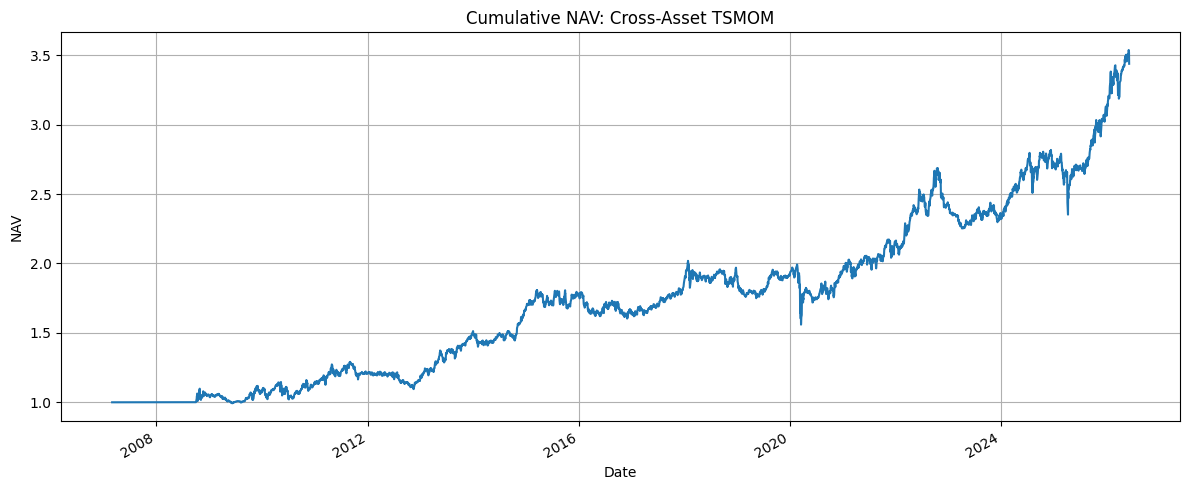

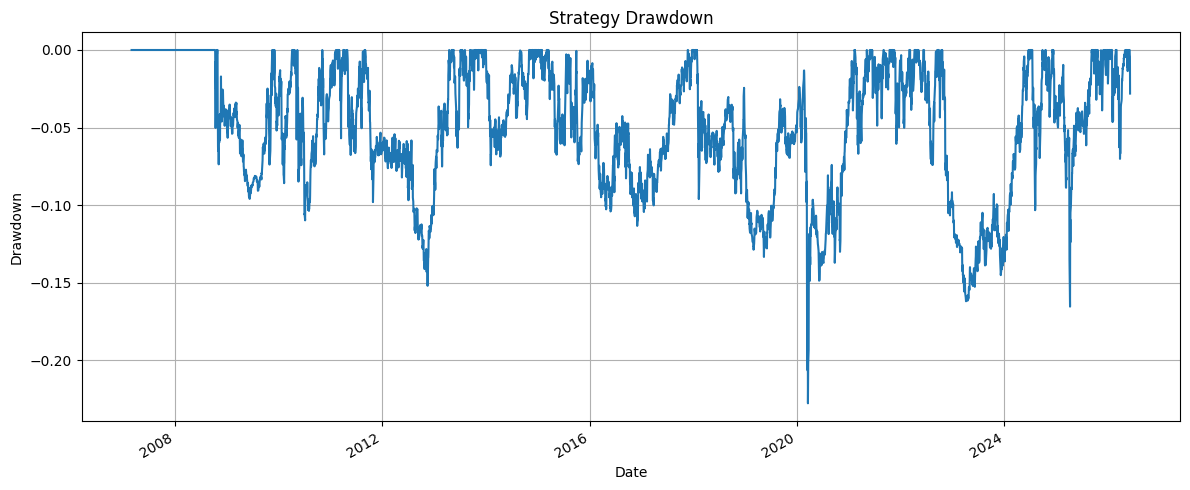

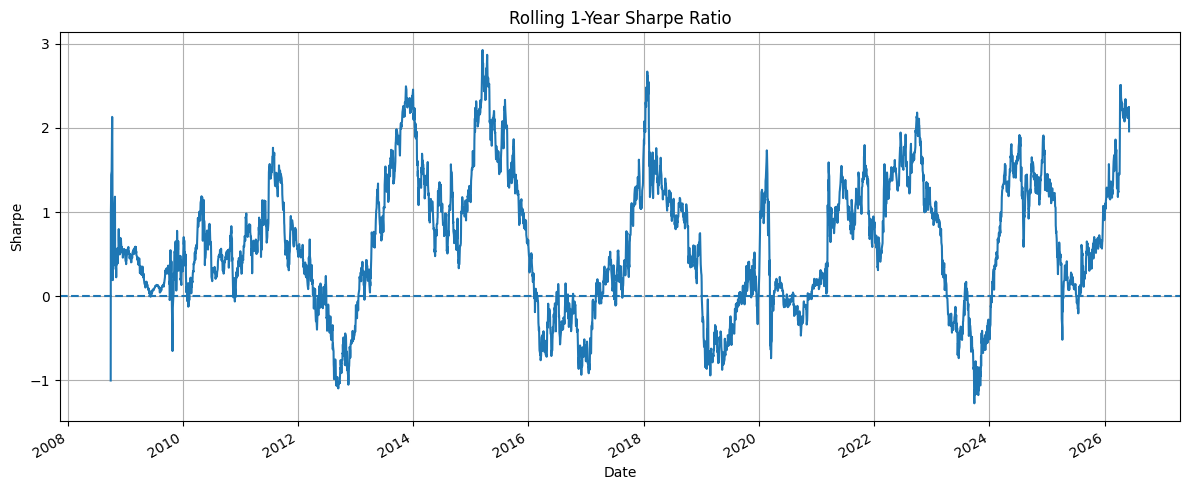

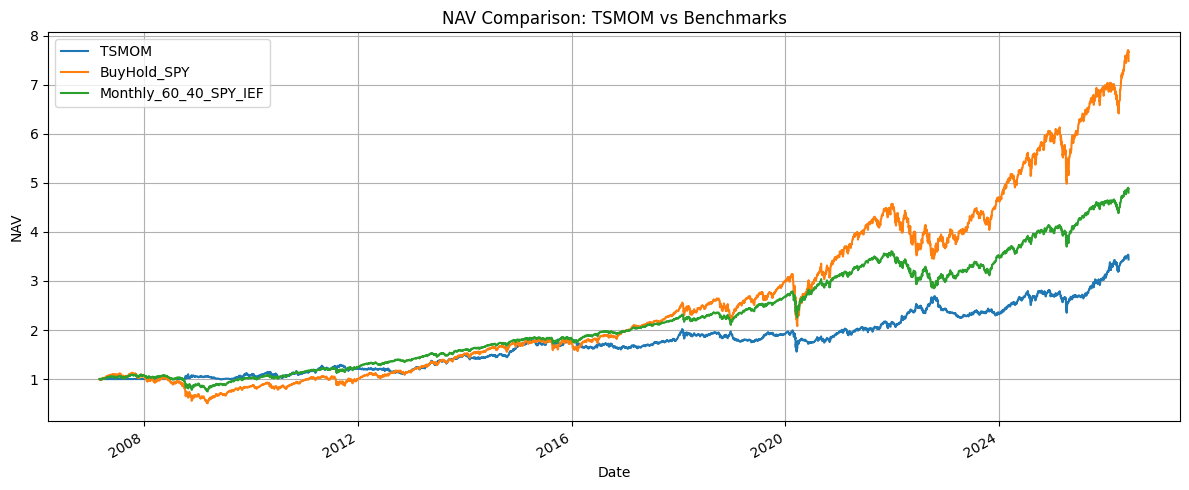

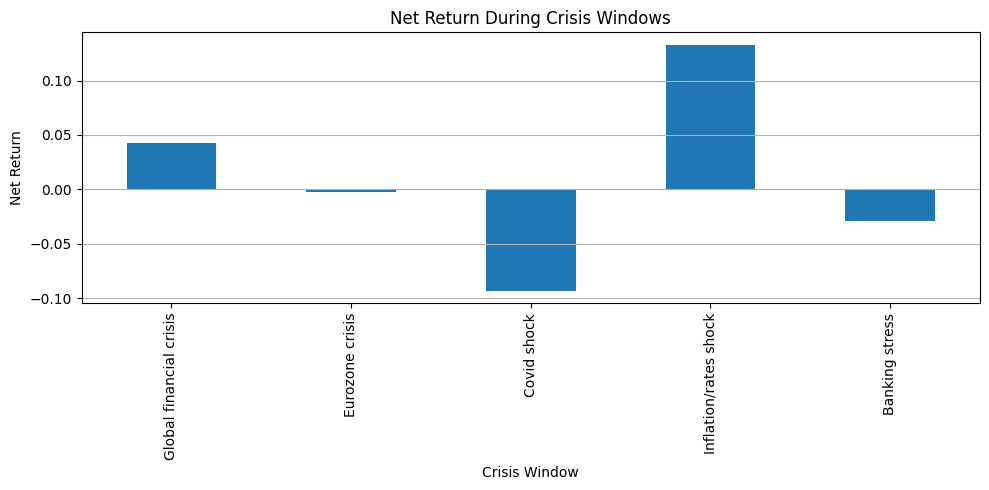

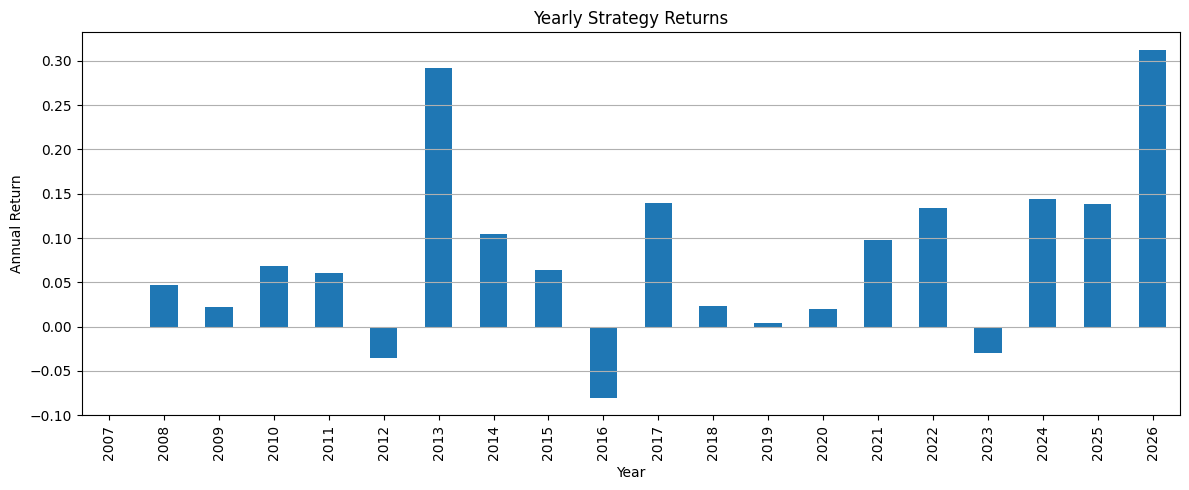

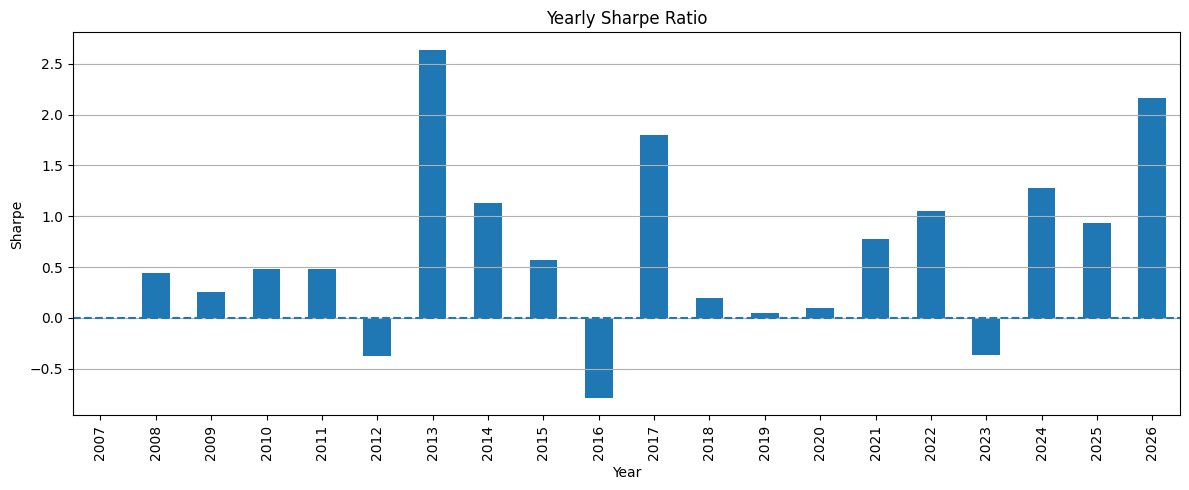

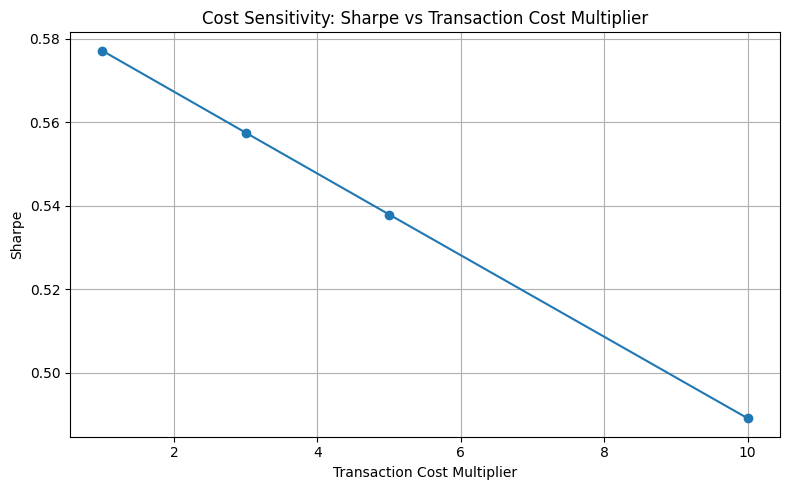

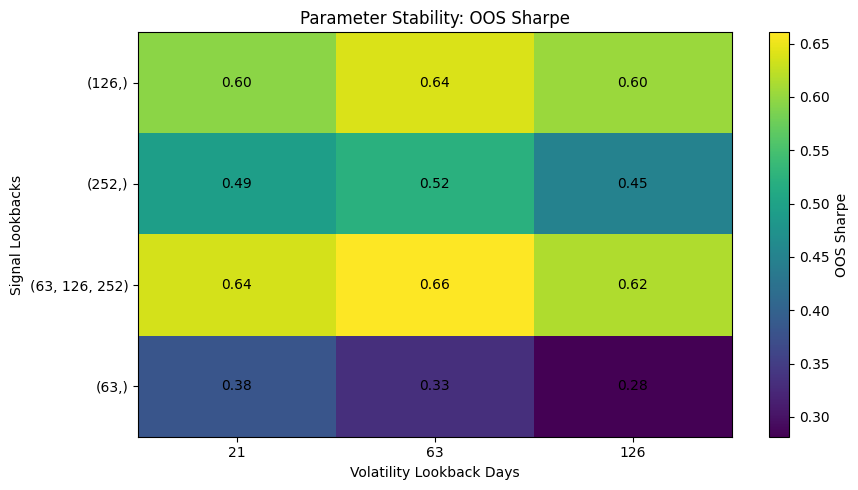

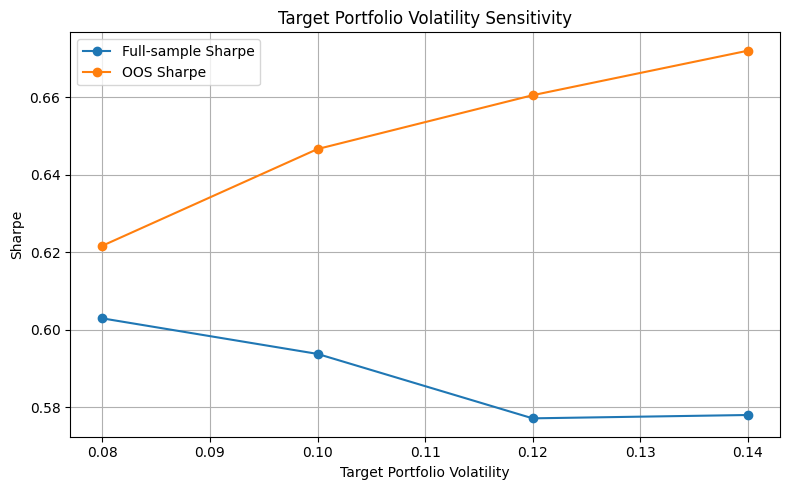

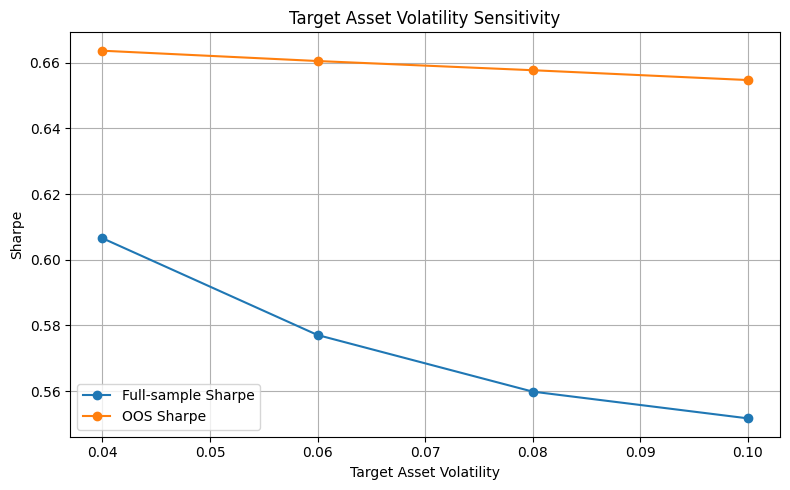

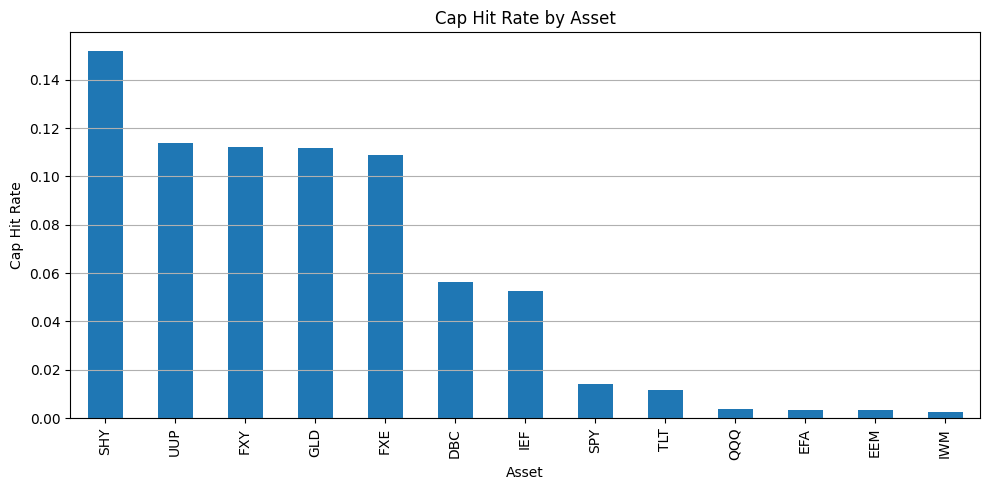

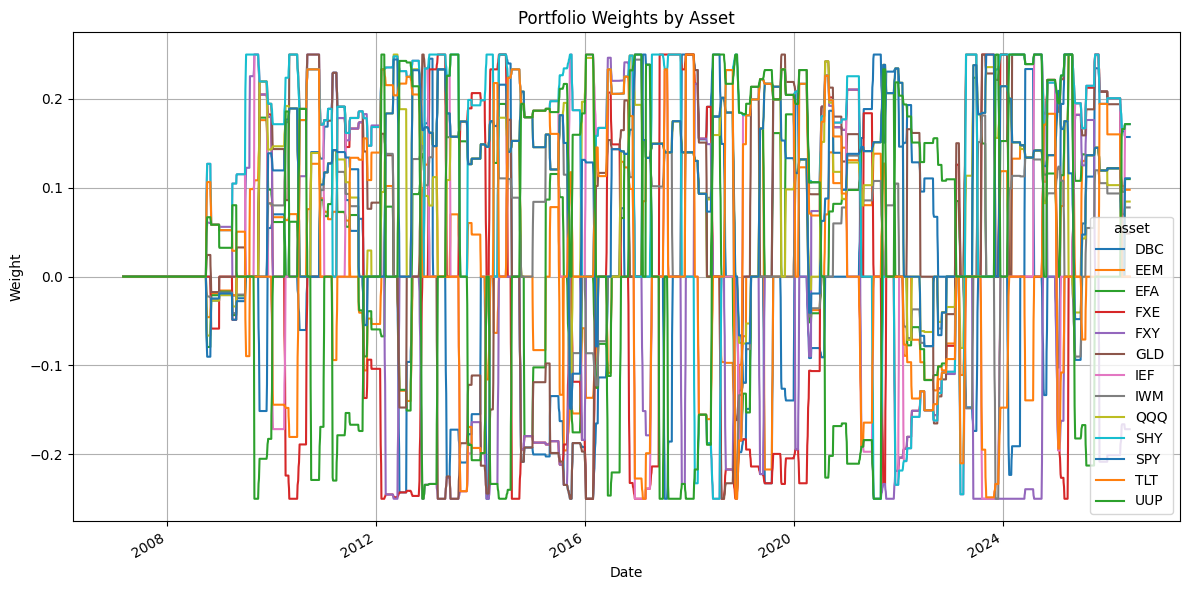

Saved GitHub figures to /figures
Saved tables to /tables


In [ ]:
# ============================================================
# GITHUB FIGURES AND TABLES
# Run after: outputs = run_full_research(price_csv_path)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)

result = outputs["result"]
weights = outputs["weights"]
prices = outputs["prices"]
returns = outputs["returns"]
full_summary = outputs["full_summary"]
split_summary = outputs["split_summary"]
crisis = outputs["crisis"]
stability = outputs["stability"]
cost_sensitivity = outputs["cost_sensitivity"]
target_vol_sensitivity = outputs["target_vol_sensitivity"]
target_asset_vol_sensitivity = outputs["target_asset_vol_sensitivity"]
benchmarks = outputs["benchmarks"]


# ============================================================
# 1. SAVE MARKDOWN TABLES FOR README
# ============================================================

def save_markdown_table(df, path, float_format=".4f"):
    table = df.copy()
    for col in table.columns:
        if pd.api.types.is_numeric_dtype(table[col]):
            table[col] = table[col].map(lambda x: f"{x:{float_format}}" if pd.notna(x) else "")
    with open(path, "w") as f:
        f.write(table.to_markdown(index=True))


full_summary.to_frame("value").to_csv("tables/full_summary.csv")
split_summary.to_csv("tables/in_sample_vs_oos.csv")
crisis.to_csv("tables/crisis_attribution.csv", index=False)
stability.to_csv("tables/parameter_stability.csv", index=False)
cost_sensitivity.to_csv("tables/cost_sensitivity.csv", index=False)
target_vol_sensitivity.to_csv("tables/target_vol_sensitivity.csv", index=False)
target_asset_vol_sensitivity.to_csv("tables/target_asset_vol_sensitivity.csv", index=False)
benchmarks.to_csv("tables/benchmark_comparison.csv")

save_markdown_table(full_summary.to_frame("value"), "tables/full_summary.md")
save_markdown_table(split_summary, "tables/in_sample_vs_oos.md")
save_markdown_table(benchmarks, "tables/benchmark_comparison.md")


# ============================================================
# 2. CUMULATIVE NAV
# ============================================================

plt.figure(figsize=(12, 5))
result["nav"].plot()
plt.title("Cumulative NAV: Cross-Asset TSMOM")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/nav.png", dpi=200)
plt.show()


# ============================================================
# 3. DRAWDOWN
# ============================================================

drawdown = result["nav"] / result["nav"].cummax() - 1.0

plt.figure(figsize=(12, 5))
drawdown.plot()
plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/drawdown.png", dpi=200)
plt.show()


# ============================================================
# 4. ROLLING 1-YEAR SHARPE
# ============================================================

rolling_return = result["net_return"].rolling(252).mean() * 252
rolling_vol = result["net_return"].rolling(252).std() * np.sqrt(252)
rolling_sharpe = rolling_return / rolling_vol

plt.figure(figsize=(12, 5))
rolling_sharpe.plot()
plt.axhline(0, linestyle="--")
plt.title("Rolling 1-Year Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/rolling_sharpe.png", dpi=200)
plt.show()


# ============================================================
# 5. BENCHMARK NAV COMPARISON
# ============================================================

benchmark_nav = pd.DataFrame(index=result.index)
benchmark_nav["TSMOM"] = result["nav"]

if "SPY" in prices.columns:
    spy_r = prices["SPY"].pct_change(fill_method=None).reindex(result.index).fillna(0.0)
    benchmark_nav["BuyHold_SPY"] = (1.0 + spy_r).cumprod()

if "SPY" in prices.columns and "IEF" in prices.columns:
    spy_r = prices["SPY"].pct_change(fill_method=None).reindex(result.index).fillna(0.0)
    ief_r = prices["IEF"].pct_change(fill_method=None).reindex(result.index).fillna(0.0)
    r6040 = 0.60 * spy_r + 0.40 * ief_r
    benchmark_nav["Monthly_60_40_SPY_IEF"] = (1.0 + r6040).cumprod()

plt.figure(figsize=(12, 5))
benchmark_nav.plot(ax=plt.gca())
plt.title("NAV Comparison: TSMOM vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/benchmark_nav.png", dpi=200)
plt.show()


# ============================================================
# 6. CRISIS RETURNS
# ============================================================

crisis_plot = crisis.set_index("crisis")["net_return"]

plt.figure(figsize=(10, 5))
crisis_plot.plot(kind="bar")
plt.title("Net Return During Crisis Windows")
plt.xlabel("Crisis Window")
plt.ylabel("Net Return")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig("figures/crisis_returns.png", dpi=200)
plt.show()


# ============================================================
# 7. YEARLY PERFORMANCE
# ============================================================

yearly = outputs["yearly"].set_index("year")

plt.figure(figsize=(12, 5))
yearly["annual_return"].plot(kind="bar")
plt.title("Yearly Strategy Returns")
plt.xlabel("Year")
plt.ylabel("Annual Return")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig("figures/yearly_returns.png", dpi=200)
plt.show()

plt.figure(figsize=(12, 5))
yearly["sharpe"].plot(kind="bar")
plt.axhline(0, linestyle="--")
plt.title("Yearly Sharpe Ratio")
plt.xlabel("Year")
plt.ylabel("Sharpe")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig("figures/yearly_sharpe.png", dpi=200)
plt.show()


# ============================================================
# 8. COST SENSITIVITY
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(cost_sensitivity["cost_multiplier"], cost_sensitivity["sharpe"], marker="o")
plt.title("Cost Sensitivity: Sharpe vs Transaction Cost Multiplier")
plt.xlabel("Transaction Cost Multiplier")
plt.ylabel("Sharpe")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/cost_sensitivity.png", dpi=200)
plt.show()


# ============================================================
# 9. PARAMETER STABILITY HEATMAP
# ============================================================

pivot = stability.pivot(
    index="signal_lookbacks",
    columns="vol_lookback_days",
    values="oos_sharpe",
)

plt.figure(figsize=(9, 5))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(np.arange(len(pivot.columns)), pivot.columns)
plt.yticks(np.arange(len(pivot.index)), pivot.index)
plt.colorbar(label="OOS Sharpe")
plt.title("Parameter Stability: OOS Sharpe")
plt.xlabel("Volatility Lookback Days")
plt.ylabel("Signal Lookbacks")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, f"{pivot.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.savefig("figures/parameter_stability_oos_sharpe.png", dpi=200)
plt.show()


# ============================================================
# 10. TARGET VOL SENSITIVITY
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    target_vol_sensitivity["target_portfolio_vol"],
    target_vol_sensitivity["sharpe"],
    marker="o",
    label="Full-sample Sharpe",
)
plt.plot(
    target_vol_sensitivity["target_portfolio_vol"],
    target_vol_sensitivity["oos_sharpe"],
    marker="o",
    label="OOS Sharpe",
)
plt.title("Target Portfolio Volatility Sensitivity")
plt.xlabel("Target Portfolio Volatility")
plt.ylabel("Sharpe")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/target_vol_sensitivity.png", dpi=200)
plt.show()


# ============================================================
# 11. TARGET ASSET VOL SENSITIVITY
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    target_asset_vol_sensitivity["target_asset_vol"],
    target_asset_vol_sensitivity["sharpe"],
    marker="o",
    label="Full-sample Sharpe",
)
plt.plot(
    target_asset_vol_sensitivity["target_asset_vol"],
    target_asset_vol_sensitivity["oos_sharpe"],
    marker="o",
    label="OOS Sharpe",
)
plt.title("Target Asset Volatility Sensitivity")
plt.xlabel("Target Asset Volatility")
plt.ylabel("Sharpe")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/target_asset_vol_sensitivity.png", dpi=200)
plt.show()


# ============================================================
# 12. CAP UTILISATION
# ============================================================

cap_report = cap_utilization_report(
    weights=weights,
    max_abs_weight_per_asset=StrategyConfig().max_abs_weight_per_asset,
)

plt.figure(figsize=(10, 5))
cap_report["cap_hit_rate"].plot(kind="bar")
plt.title("Cap Hit Rate by Asset")
plt.xlabel("Asset")
plt.ylabel("Cap Hit Rate")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig("figures/cap_utilisation.png", dpi=200)
plt.show()


# ============================================================
# 13. ASSET WEIGHTS
# ============================================================

plt.figure(figsize=(12, 6))
weights.plot(ax=plt.gca())
plt.title("Portfolio Weights by Asset")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/asset_weights.png", dpi=200)
plt.show()


print("Saved GitHub figures to /figures")
print("Saved tables to /tables")

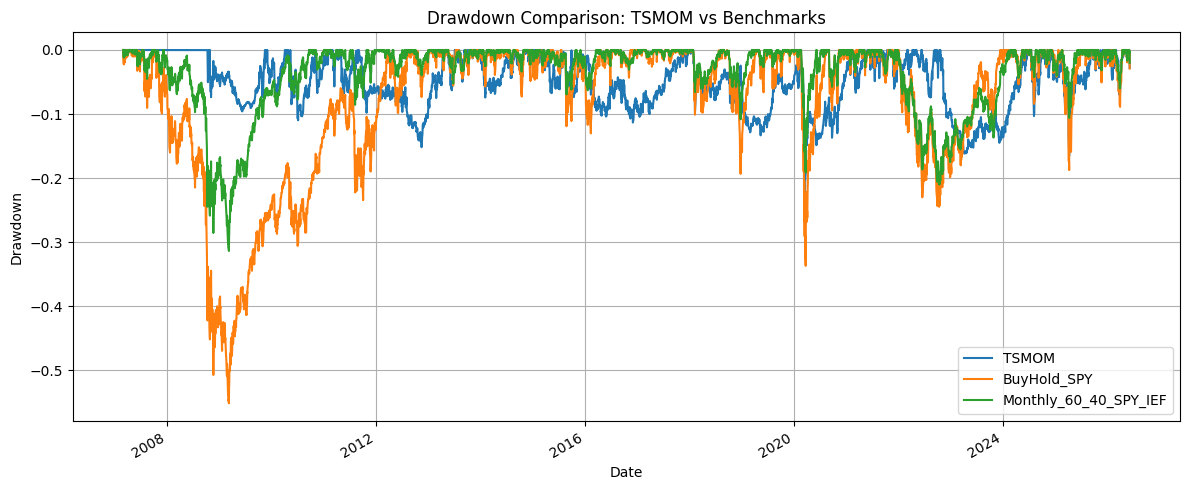

In [ ]:
# ============================================================
# DRAWDOWN COMPARISON: TSMOM VS BENCHMARKS
# Run after outputs = run_full_research(price_csv_path)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

result = outputs["result"]
prices = outputs["prices"]

comparison_returns = pd.DataFrame(index=result.index)

comparison_returns["TSMOM"] = result["net_return"]

if "SPY" in prices.columns:
    comparison_returns["BuyHold_SPY"] = (
        prices["SPY"]
        .pct_change(fill_method=None)
        .reindex(result.index)
        .fillna(0.0)
    )

if "SPY" in prices.columns and "IEF" in prices.columns:
    spy_r = prices["SPY"].pct_change(fill_method=None).reindex(result.index).fillna(0.0)
    ief_r = prices["IEF"].pct_change(fill_method=None).reindex(result.index).fillna(0.0)
    comparison_returns["Monthly_60_40_SPY_IEF"] = 0.60 * spy_r + 0.40 * ief_r

comparison_nav = (1.0 + comparison_returns).cumprod()
comparison_drawdown = comparison_nav / comparison_nav.cummax() - 1.0

plt.figure(figsize=(12, 5))
comparison_drawdown.plot(ax=plt.gca())
plt.title("Drawdown Comparison: TSMOM vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/drawdown_comparison.png", dpi=200)
plt.show()